In [7]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
# load all sheets into a dictionary of dataframes
dfs = pd.read_excel(r'../data/raw/VRP_Sri_Lanka_Dataset.xlsx', sheet_name=None)
print(dfs)
# Delivery_Order sheet
delivery_orders = dfs['Delivery_Orders']

# Vehicle_Fleet sheet
vehicle_fleet = dfs['Vehicle_Fleet']

# Road_Speed_Lookup sheet
road_speed_lookup = dfs['Road_Speed_Lookup']

print("Successfully loaded all sheets into dataframes.")

{'Delivery_Orders':     Order_ID         City_Name       Province  Latitude  Longitude  \
0    ORD-000           Colombo        Western    6.9271    79.8612   
1    ORD-001            Mannar       Northern    8.9930    79.9039   
2    ORD-002          Ahangama       Southern    5.9601    80.3600   
3    ORD-003    Tissamaharama        Southern    6.2808    81.2885   
4    ORD-004          PANADURA        Western    6.7073    79.8970   
..       ...               ...            ...       ...        ...   
195  ORD-127     Tissamaharama       Southern    6.2805    81.2894   
196  ORD-096         Wattegama        Central    7.3273    80.6507   
197  ORD-028         Hikkaduwa       Southern    6.1389    80.0967   
198  ORD-162            Ja-Ela        Western    7.0695    79.8981   
199  ORD-119          KEKIRAWA  North Central    8.0344    80.5699   

    Cargo_Weight_kg Road_Condition Priority_Level  Order_Value_LKR  \
0                 0      Excellent              0              0.0   

In [10]:
print("==================================================")
print("         DIAGNOSTIC & STRING CORRUPTION           ")
print("==================================================")

# Audit Priority level
print("Auditing Priority levels in Delivery_Orders sheet...")
print(delivery_orders['Priority_Level'].value_counts(dropna=False))

# Audit cargo weight
print("Auditing Cargo_Weight in Delivery_Orders sheet...")
corrupted_cargo_weight = delivery_orders[pd.to_numeric(delivery_orders['Cargo_Weight_kg'], errors='coerce').isnull() & delivery_orders['Cargo_Weight_kg'].notnull()]
if not corrupted_cargo_weight.empty:
    display(corrupted_cargo_weight[['Order_ID', 'Cargo_Weight_kg','City_Name']].head(10))
else:
    print("No corrupted Cargo_Weight_kg values found.")

# Audit Order value
print("Auditing Order_Value_LKR in Delivery_Orders sheet...")
corrupted_order_value = delivery_orders[pd.to_numeric(delivery_orders['Order_Value_LKR'], errors ='coerce').isnull() & delivery_orders['Order_Value_LKR'].notnull()]
if not corrupted_order_value.empty:
    display(corrupted_order_value[['Order_ID', 'Order_Value_LKR','City_Name']].head(10))
else:
    print("No corrupted Order_Value_LKR values found.")

         DIAGNOSTIC & STRING CORRUPTION           
Auditing Priority levels in Delivery_Orders sheet...
Priority_Level
3       67
4       40
2       34
5       28
1       25
High     3
6        2
0        1
Name: count, dtype: int64
Auditing Cargo_Weight in Delivery_Orders sheet...


,Order_ID,Cargo_Weight_kg,City_Name
59,ORD-059,2089 kg,Peliyagoda
134,ORD-134,997 kg,Panadura
140,ORD-140,2176 kg,Kayts
144,ORD-144,1923 kg,Welimada
154,ORD-154,1087 kg,Dehiwala
190,ORD-190,1215 kg,Ratnapura


Auditing Order_Value_LKR in Delivery_Orders sheet...
No corrupted Order_Value_LKR values found.


In [11]:
print("==================================================")
print("             EXECUTE TYPE ENFORCEMENT             ")
print("==================================================")

# Clean priority level
delivery_orders['Priority_Level'] = delivery_orders['Priority_Level'].replace({'High': 5, 'high': 5})

# any remaining nulls or text values, fill or handle them before integer conversion
delivery_orders['Priority_Level'] = pd.to_numeric(delivery_orders['Priority_Level'], errors='coerce').fillna(0).astype(int)
print("Priority_Level column cleaned and converted to integer.")

# Numeric conversion for Cargo_Weight_kg and Order_Value_LKR
delivery_orders['Cargo_Weight_kg'] = delivery_orders['Cargo_Weight_kg'].astype(str).str.lower().str.replace('kg', '').str.replace(',', '').str.strip()
delivery_orders['Cargo_Weight_kg'] = pd.to_numeric(delivery_orders['Cargo_Weight_kg'], errors='coerce')
print("Cargo_Weight_kg column cleaned and converted to numeric.")

delivery_orders['Order_Value_LKR'] = delivery_orders['Order_Value_LKR'].astype(str).str.lower().str.replace('lkr', '').str.replace(',', '').str.strip()
delivery_orders['Order_Value_LKR'] = pd.to_numeric(delivery_orders['Order_Value_LKR'], errors='coerce')
print("Order_Value_LKR column cleaned and converted to numeric.")


print("Post transformation data types:")
print(delivery_orders[['Priority_Level', 'Cargo_Weight_kg', 'Order_Value_LKR']].dtypes)

             EXECUTE TYPE ENFORCEMENT             
Priority_Level column cleaned and converted to integer.
Cargo_Weight_kg column cleaned and converted to numeric.
Order_Value_LKR column cleaned and converted to numeric.
Post transformation data types:
Priority_Level       int64
Cargo_Weight_kg    float64
Order_Value_LKR    float64
dtype: object


C:\Users\User\AppData\Local\Temp\ipykernel_41172\2785376883.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  delivery_orders['Priority_Level'] = delivery_orders['Priority_Level'].replace({'High': 5, 'high': 5})


        DIAGNOSTIC & SPATIAL IDENTIFICATION       
Checking for duplicates in city names in Delivery_Orders sheet...
City_Name
Kegalle          5
Kalutara         5
Wattegama        5
Ambalangoda      5
Kotte            5
Matale           4
Valachchenai     4
Ahangama         4
Dehiwala         4
Tissamaharama    4
Name: count, dtype: int64
Checking for gaps in cargo weight in Delivery_Orders sheet...


,Order_ID,City_Name,Province,Cargo_Weight_kg
15,ORD-015,Beliatta,Southern,NaN
27,ORD-027,Polonnaruwa,North Central,NaN
38,ORD-038,Hikkaduwa,Southern,NaN
51,ORD-051,Mount Lavinia,Western,NaN
63,ORD-063,Maharagama,Western,NaN
66,ORD-066,Beliatta,Southern,NaN
69,ORD-069,Wattegama,Central,NaN
76,ORD-076,Kaduwela,Western,NaN
95,ORD-095,Badulla,Uva,NaN
96,ORD-096,Wattegama,Central,NaN


Visualizing the imputation strategy for missing cargo weights using province medians...


,Province,Cargo_Weight_kg
0,Central,1664.0
1,Eastern,1662.5
2,North Central,2104.0
3,North Western,2067.0
4,Northern,1705.0
5,Sabaragamuwa,1817.0
6,Southern,1818.0
7,Uva,1743.0
8,Western,1428.0
9,eastern,850.0


C:\Users\User\AppData\Local\Temp\ipykernel_41172\1072514311.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=province_medians, x='Province', y='Cargo_Weight_kg', palette='viridis')


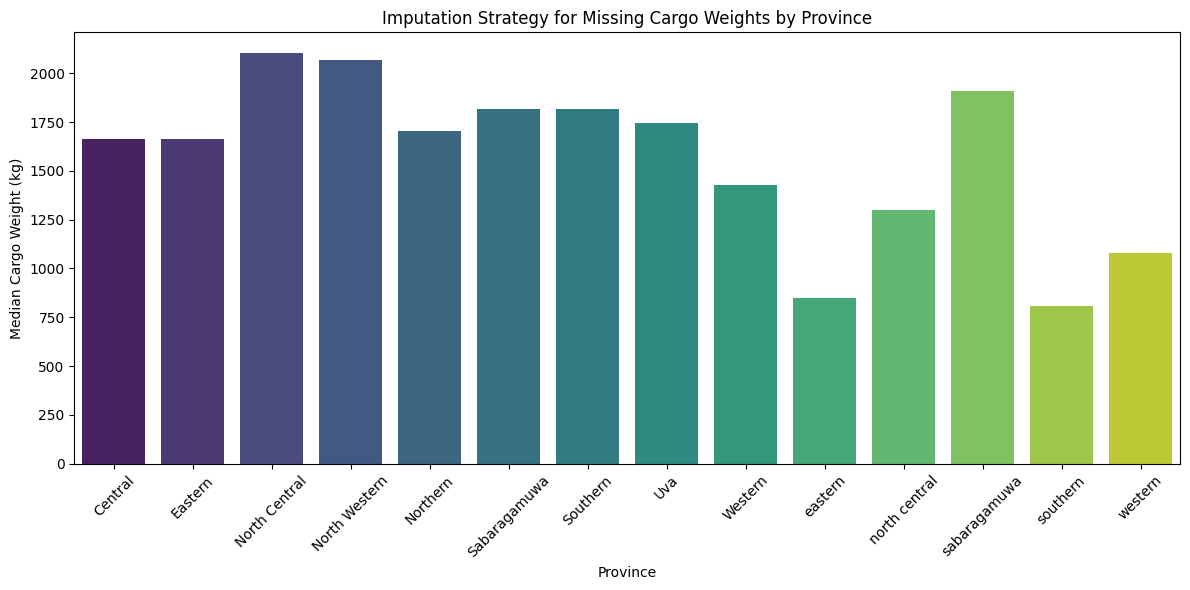

In [12]:
print("==================================================")
print("        DIAGNOSTIC & SPATIAL IDENTIFICATION       ")
print("==================================================")

# Identify anomalies in the data
print("Checking for duplicates in city names in Delivery_Orders sheet...")
delivery_orders_duplicates = delivery_orders['City_Name'].value_counts().head(10)
print(delivery_orders_duplicates)


# Gaps in cargo weight
print("Checking for gaps in cargo weight in Delivery_Orders sheet...")
missing_cargo_weight = delivery_orders[delivery_orders['Cargo_Weight_kg'].isnull()]
display(missing_cargo_weight[['Order_ID', 'City_Name', 'Province', 'Cargo_Weight_kg']])


# Visualize the Imputation Strategy province medians
print("Visualizing the imputation strategy for missing cargo weights using province medians...")
province_medians = delivery_orders.groupby('Province')['Cargo_Weight_kg'].median().reset_index()
display(province_medians)

plt.figure(figsize=(12, 6))
sns.barplot(data=province_medians, x='Province', y='Cargo_Weight_kg', palette='viridis')
plt.title('Imputation Strategy for Missing Cargo Weights by Province')
plt.xlabel('Province')
plt.ylabel('Median Cargo Weight (kg)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

print("==================================================")
print("             EXECUTE TYPE ENFORCEMENT             ")
print("==================================================")

# text standarization
# ensure delivery_orders is the DataFrame (fall back to dfs['Delivery_Orders'] if needed)
if isinstance(delivery_orders, pd.Series) or 'City_Name' not in getattr(delivery_orders, 'columns', []):
    if isinstance(dfs, dict) and 'Delivery_Orders' in dfs:
        delivery_orders = dfs['Delivery_Orders'].copy()

# Standardize City_Name if present
if 'City_Name' in delivery_orders.columns:
    delivery_orders['City_Name'] = delivery_orders['City_Name'].astype(str).str.title().str.strip()
print("City_Name column standardized to title case and stripped")

# Inject the province median cargo weight into the missing values
delivery_orders = delivery_orders['Cargo_Weight_kg'].fillna(delivery_orders.groupby('Province')['Cargo_Weight_kg'].transform('median'))
print("Missing cargo weight values filled with province median values")

print("Post Transformation Verification:")
verified_missing_cargo_weight = delivery_orders[delivery_orders['Cargo_Weight_kg'].isnull()]
display(verified_missing_cargo_weight[['Order_ID', 'City_Name', 'Province', 'Cargo_Weight_kg']])


             EXECUTE TYPE ENFORCEMENT             


KeyError: 'City_Name'